In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style='darkgrid', palette='Dark2')
from sklearn.linear_model import LinearRegression

In [2]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'


In [3]:
data=pd.read_csv('medical.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
data.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


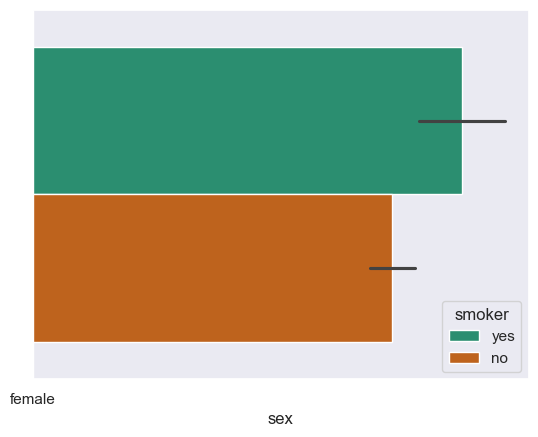

In [6]:
sns.barplot(x=data.sex  , hue=data.smoker )
plt.show()

<Axes: xlabel='age', ylabel='charges'>

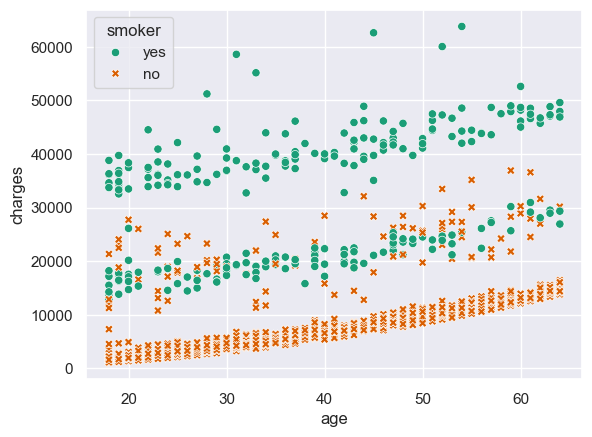

In [7]:
sns.scatterplot(x=data.age , y = data.charges ,hue=data.smoker , style=data.smoker)

<Axes: xlabel='age', ylabel='bmi'>

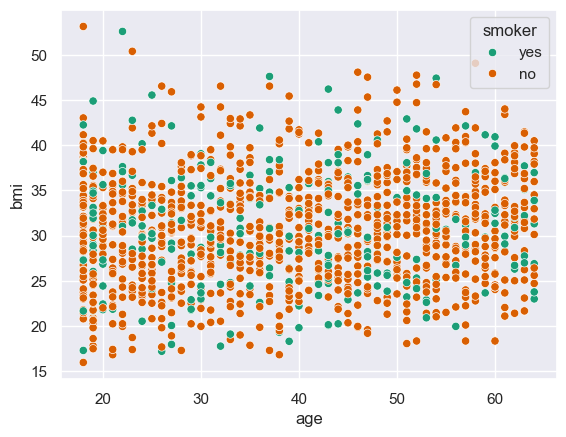

In [8]:
sns.scatterplot(x=data.age , y=data.bmi, hue=data.smoker  )

<Axes: xlabel='smoker', ylabel='charges'>

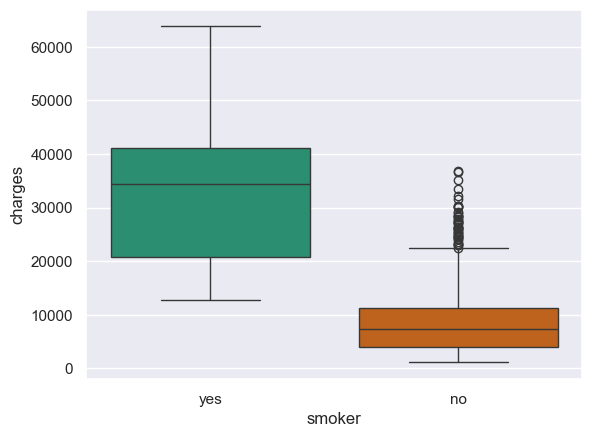

In [9]:
sns.boxplot(x=data.smoker , y=data.charges, hue=data.smoker)

<Axes: xlabel='bmi', ylabel='Count'>

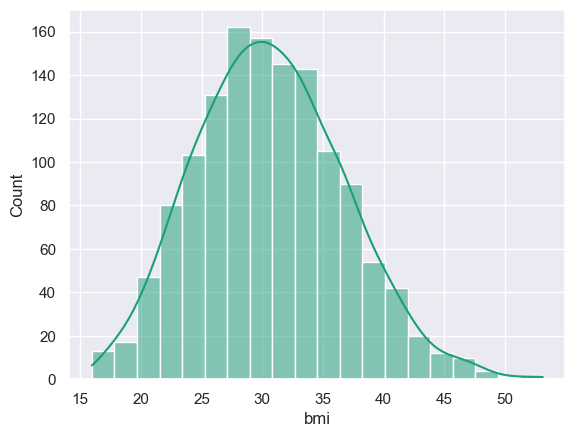

In [10]:
sns.histplot(data.bmi,bins=20,kde=True)

<Axes: xlabel='smoker', ylabel='count'>

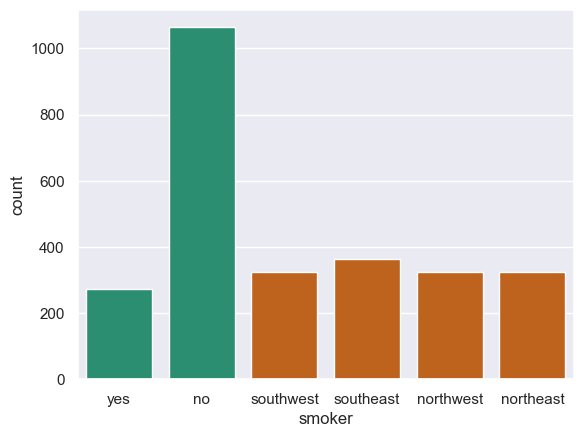

In [11]:
sns.countplot(x=data.smoker)
sns.countplot(x=data.region)

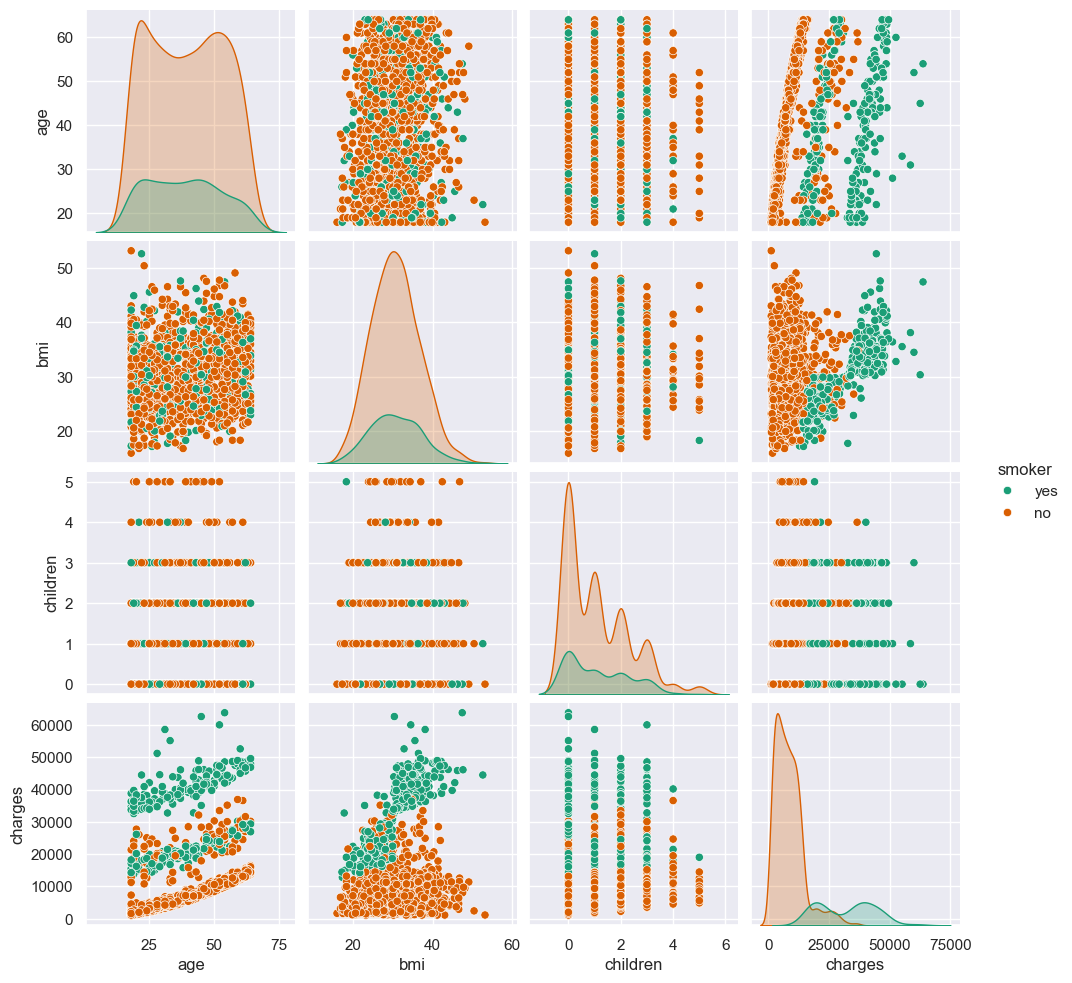

In [12]:
sns.pairplot(data, hue='smoker')

<Axes: xlabel='age', ylabel='Count'>

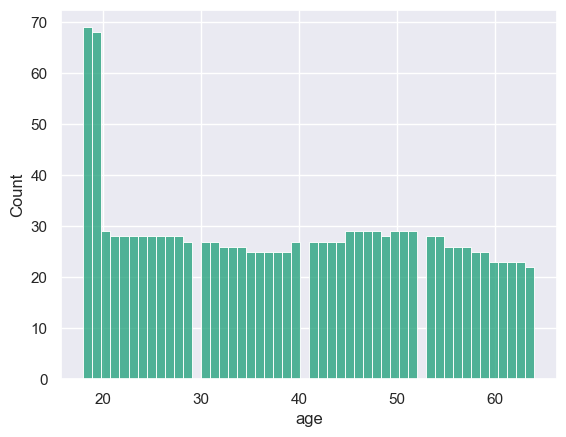

In [13]:
sns.histplot(data.age,bins=50 )

<Axes: xlabel='bmi', ylabel='charges'>

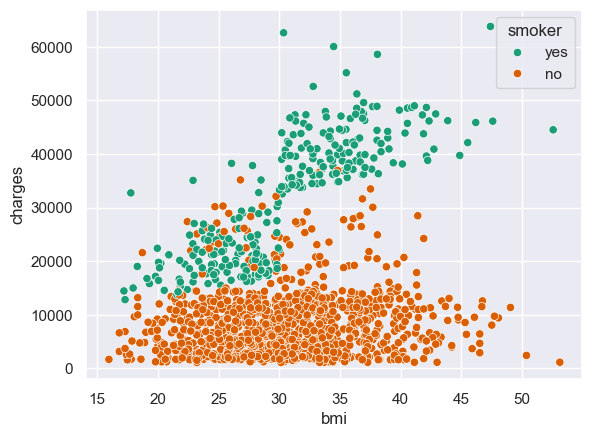

In [14]:
sns.scatterplot(x=data.bmi , y = data.charges ,hue=data.smoker)

<Axes: xlabel='bmi', ylabel='Count'>

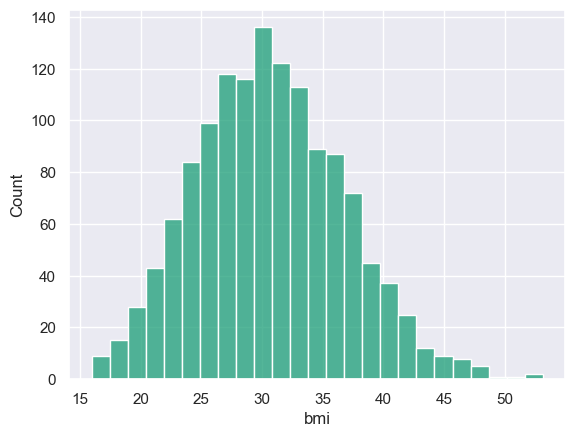

In [15]:
sns.histplot(data.bmi)

<Axes: xlabel='smoker', ylabel='Count'>

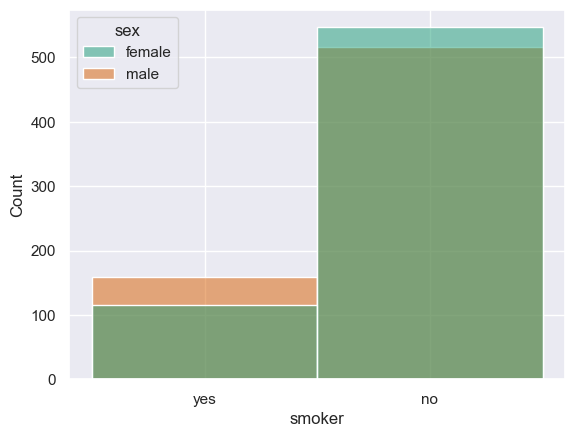

In [16]:
sns.histplot(x=data.smoker , hue=data.sex )

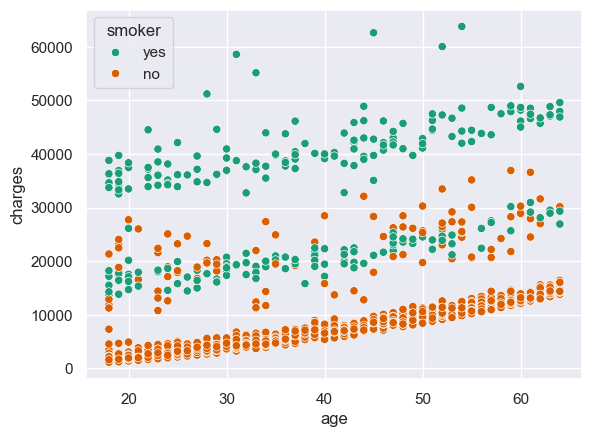

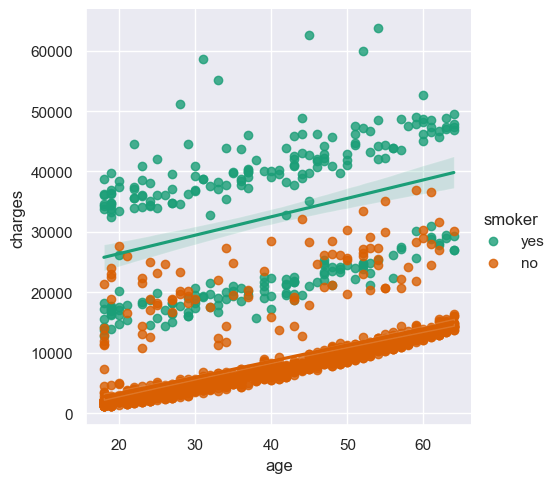

In [17]:
sns.scatterplot(x=data.age , y=data.charges , hue=data.smoker )
sns.lmplot(data=data , x='age', y='charges', hue='smoker')
plt.show()

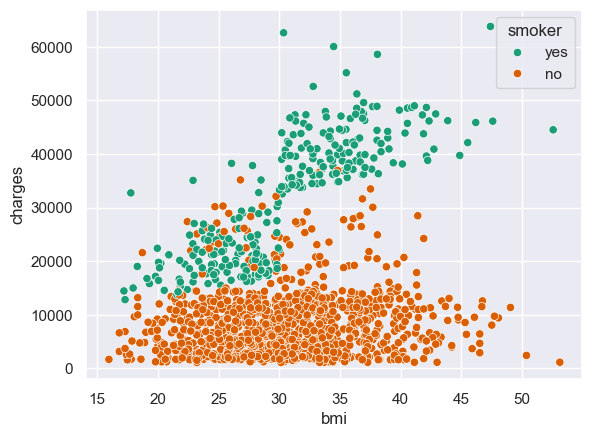

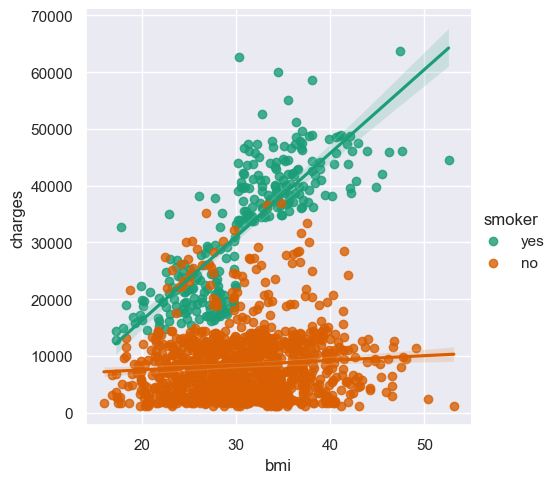

In [18]:
sns.scatterplot(x=data.bmi , y=data.charges,hue=data.smoker)
sns.lmplot(data=data , x='bmi' , y='charges' , hue='smoker')

<Axes: xlabel='children', ylabel='charges'>

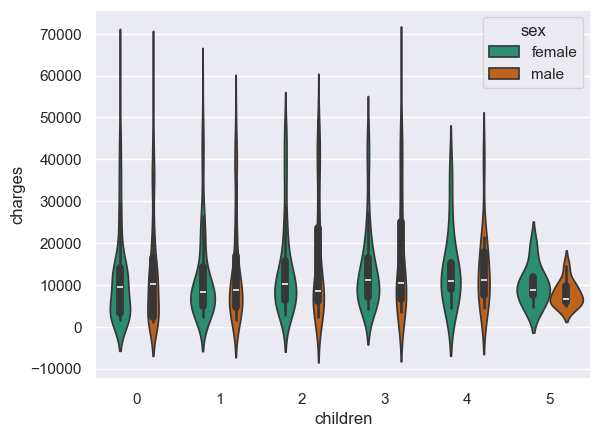

In [19]:
sns.violinplot(x=data.children , y=data.charges,hue=data.sex)

In [20]:
data.charges.corr(data.age)

np.float64(0.2990081933306476)

In [21]:
def get(sm):
    if sm=='yes':
        return 1
    else:
        return 0

smoker_numeric = data.smoker.map(get)
smoker_numeric

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1338, dtype: int64

In [22]:
data.charges.corr(smoker_numeric)

np.float64(0.7872514304984782)

In [23]:
data.age.corr(data.age)

np.float64(1.0)

<Axes: xlabel='age', ylabel='age'>

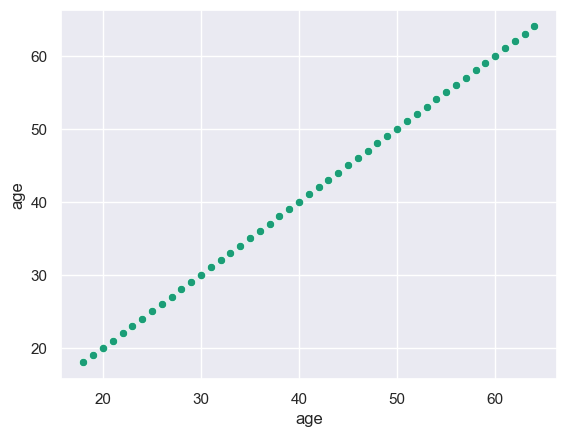

In [24]:
sns.scatterplot(x=data.age,y=data.age)

In [25]:
data.corr

<bound method DataFrame.corr of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

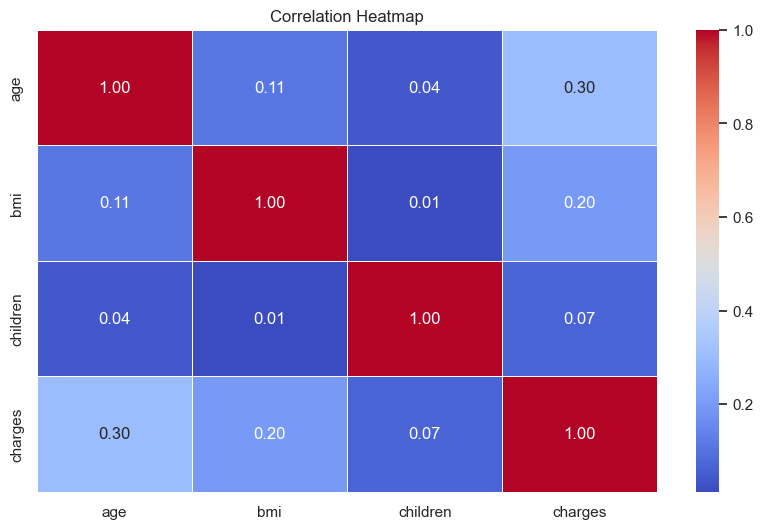

In [26]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Linear regression using single feature

In [27]:
non_smoker_df = data[data.smoker=='no']
non_smoker_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


<Axes: xlabel='age', ylabel='charges'>

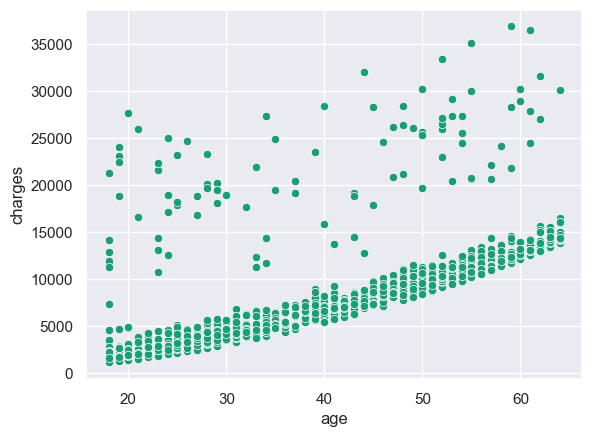

In [28]:
sns.scatterplot(x=non_smoker_df.age , y=non_smoker_df.charges)

In [29]:
def estimate_charges(m,x,c):
    return (m*x)+c

m=50
c=100


In [30]:
ages=non_smoker_df.age
ages

1       18
2       28
3       33
4       32
5       31
        ..
1332    52
1333    50
1334    18
1335    18
1336    21
Name: age, Length: 1064, dtype: int64

In [31]:
estimated_charges=estimate_charges(m,ages,c)


<Axes: xlabel='age', ylabel='age'>

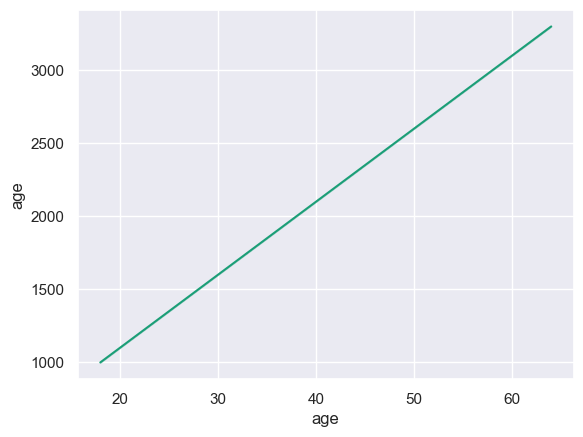

In [32]:
sns.lineplot(x=non_smoker_df.age , y=estimated_charges)

In [33]:
estimated_charges

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [34]:
non_smoker_df.charges

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

<Axes: xlabel='age', ylabel='charges'>

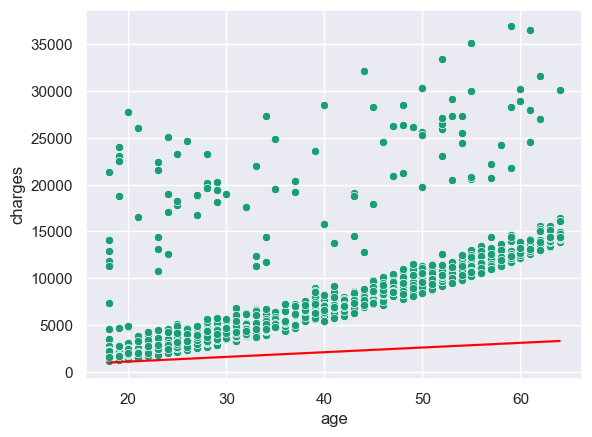

In [35]:
sns.scatterplot(x=non_smoker_df.age , y=non_smoker_df.charges)
sns.lineplot(x=non_smoker_df.age , y=estimated_charges , color='r')

In [36]:
sum=0
for i in range(len(estimated_charges)):
    sum+=((estimated_charges.iloc[i] - non_smoker_df.charges.iloc[i]) **2)

(sum/len(estimated_charges))**0.5

np.float64(8461.949562575488)

In [37]:
np.mean(non_smoker_df.charges)

np.float64(8434.268297856204)

# using scikit learn for machine learning

In [38]:
model = LinearRegression()

In [39]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [40]:
inputs=pd.DataFrame(non_smoker_df.age)# x value of fit mus be a dataframe so we do this 
targets = non_smoker_df.charges
type(inputs)

pandas.core.frame.DataFrame

In [41]:
model.fit(inputs , targets)

LinearRegression()

c:\Users\anime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


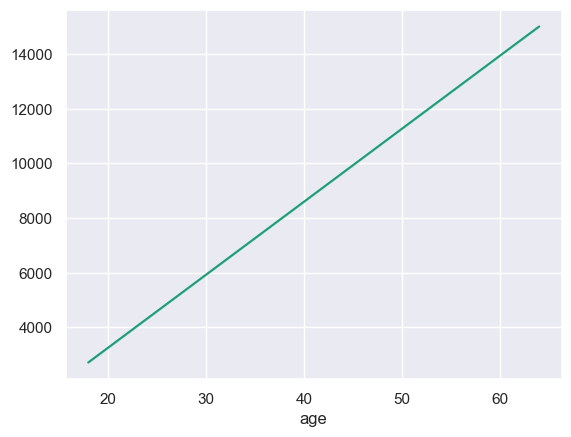

In [42]:
predicted_charges_by_model=model.predict(np.array(non_smoker_df.age).reshape(len(non_smoker_df.age),1))

new_charges=np.array(predicted_charges_by_model)

sns.lineplot(x=non_smoker_df.age , y=new_charges)
plt.show()

In [43]:
predictions = model.predict(inputs)
def rmse(targets , predictions):
     return np.sqrt(np.mean((np.array(predictions) - np.array(targets))**2))

In [44]:
rmse_value = rmse(targets,predictions)
rmse_value

np.float64(4662.505766636395)

In [45]:
model.coef_ # m value slope

array([267.24891283])

In [46]:
model.intercept_ # c value intercept

np.float64(-2091.4205565650864)

<Axes: xlabel='age', ylabel='age'>

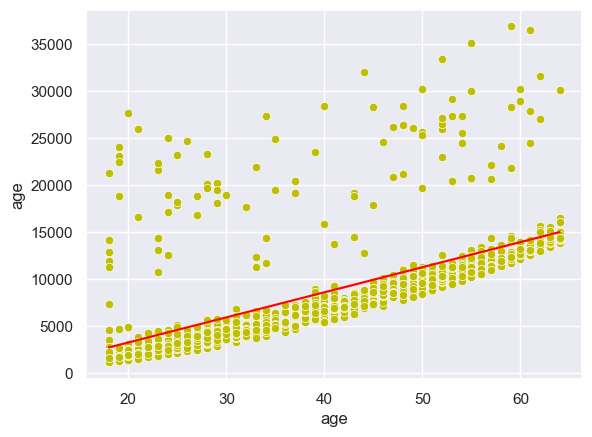

In [47]:
new_charges = estimate_charges(model.coef_  , non_smoker_df.age ,model.intercept_ )
sns.lineplot(x=non_smoker_df.age , y=new_charges , color='r')
sns.scatterplot(x=non_smoker_df.age , y=non_smoker_df.charges , color='y')

# using SGDRegressor but it gave bad answer than logistic regressor

In [48]:
from sklearn.linear_model import SGDRegressor

In [49]:
model2 = SGDRegressor()

In [50]:
x = pd.DataFrame(non_smoker_df.age)
y=non_smoker_df.charges
model2.fit(x,y)

SGDRegressor()

In [51]:
predctions2=model2.predict(x)

<Axes: xlabel='age', ylabel='charges'>

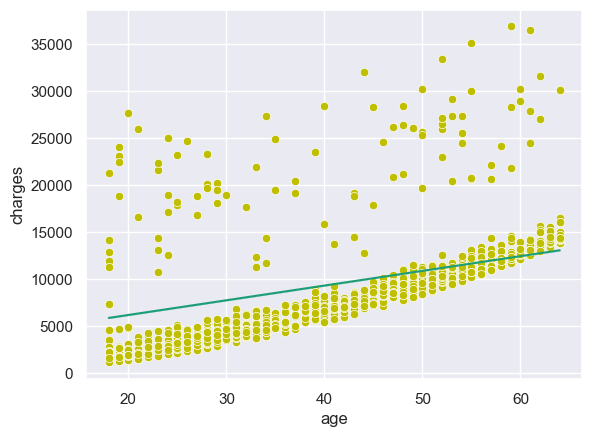

In [52]:
sns.lineplot(x=non_smoker_df.age , y=predctions2)
sns.scatterplot(x=non_smoker_df.age , y=non_smoker_df.charges , color='y')

In [53]:
rms2=rmse(non_smoker_df.charges , predctions2)
rms2

np.float64(4977.561570645233)

In [54]:
new_charges_2 = estimate_charges(model2.coef_ , non_smoker_df.age , model2.intercept_)


<Axes: xlabel='age', ylabel='charges'>

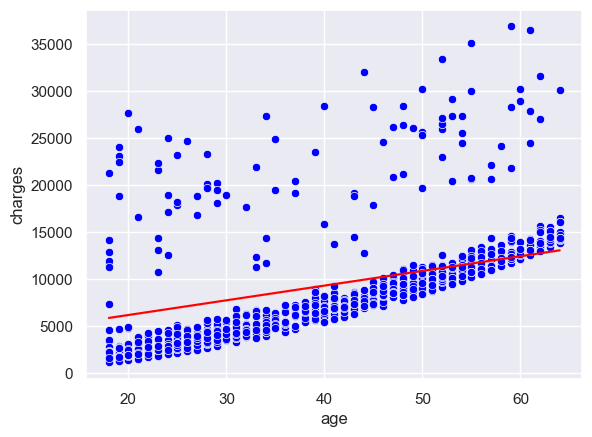

In [55]:
sns.scatterplot(x=non_smoker_df.age , y=non_smoker_df.charges , color='b')
sns.lineplot(x=non_smoker_df.age , y=new_charges_2 , color='r')

<Axes: xlabel='bmi', ylabel='charges'>

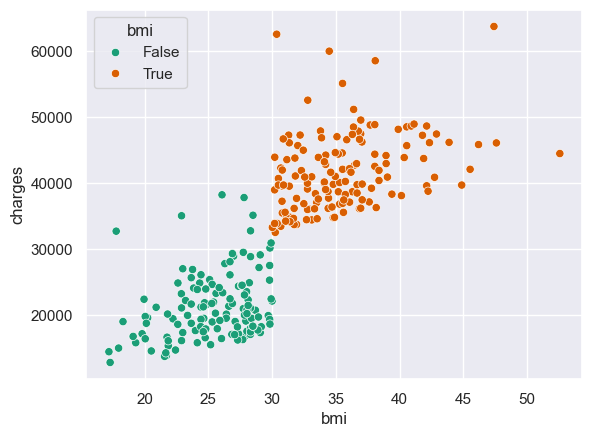

In [56]:
smoker_df = data[data.smoker=='yes']
sns.scatterplot(x=smoker_df.bmi , y=smoker_df.charges,hue=smoker_df.bmi>30)

In [57]:
smoker_df.age.corr(smoker_df.charges)

np.float64(0.36822444373077784)

In [58]:

def take(sm):
    if sm=='male':
        return 1
    else:
        return 0
t=smoker_df.sex.map(take)
smoker_df.age.corr(t)

np.float64(-0.005758137055376179)

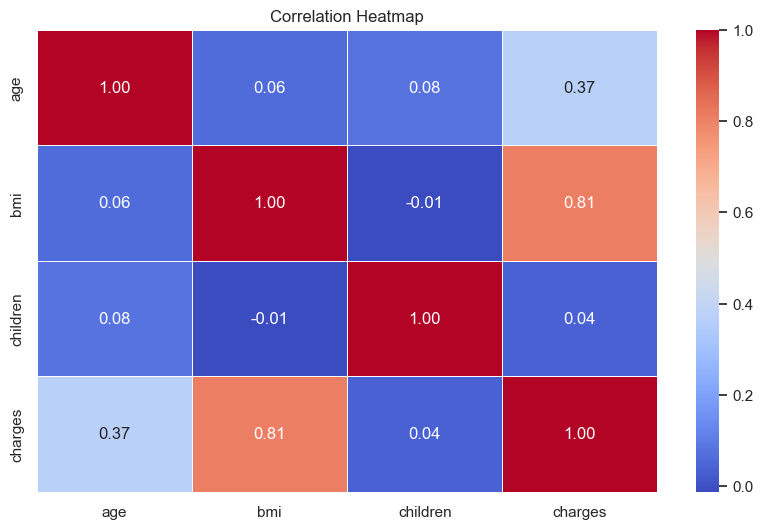

In [59]:
plt.figure(figsize=(10, 6))
sns.heatmap(smoker_df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='bmi', ylabel='charges'>

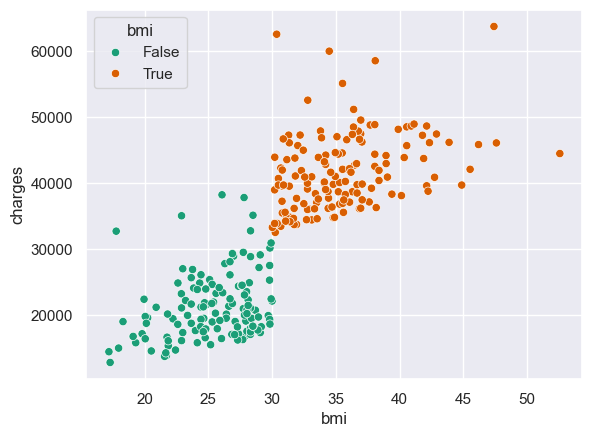

In [60]:
sns.scatterplot(x=smoker_df.bmi , y=smoker_df.charges,hue=smoker_df.bmi>30)

In [61]:
x2=pd.DataFrame(smoker_df.bmi)
y2=smoker_df.charges
model3=LinearRegression()

In [62]:
model3.fit(x2,y2)

LinearRegression()

In [63]:
new_smoker_charges = model3.predict(x2)

<Axes: xlabel='bmi', ylabel='charges'>

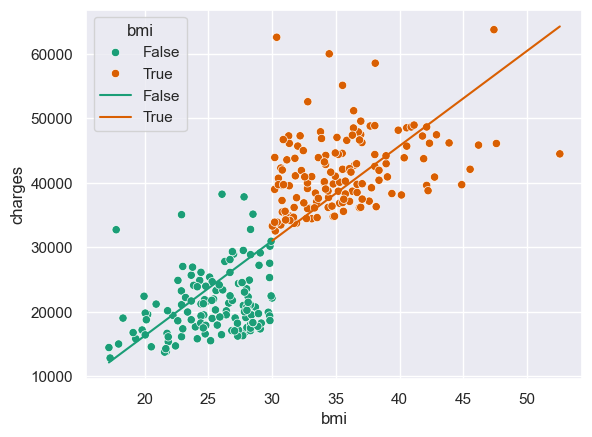

In [64]:
sns.scatterplot(x=smoker_df.bmi , y=smoker_df.charges,hue=smoker_df.bmi>30)
sns.lineplot(x=smoker_df.bmi , y=new_smoker_charges,hue=smoker_df.bmi>30 )

In [65]:
rms3=rmse(new_smoker_charges , smoker_df.charges)
rms3

np.float64(6811.59740830196)

# Profesionally implementing linear regression

In [66]:
inputs=pd.DataFrame(non_smoker_df.age)
output = non_smoker_df.charges

model = LinearRegression().fit(inputs,output)
predictions=model.predict(inputs)
loss=rmse(predictions , output)
loss

np.float64(4662.505766636395)

<Axes: xlabel='children', ylabel='charges'>

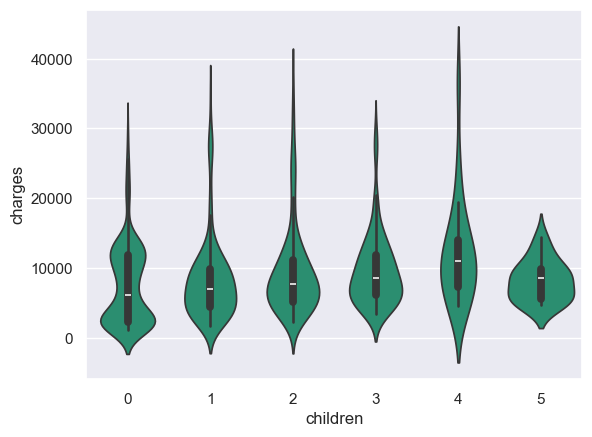

In [67]:
sns.violinplot(x=non_smoker_df.children , y=non_smoker_df.charges)

<Axes: xlabel='bmi', ylabel='charges'>

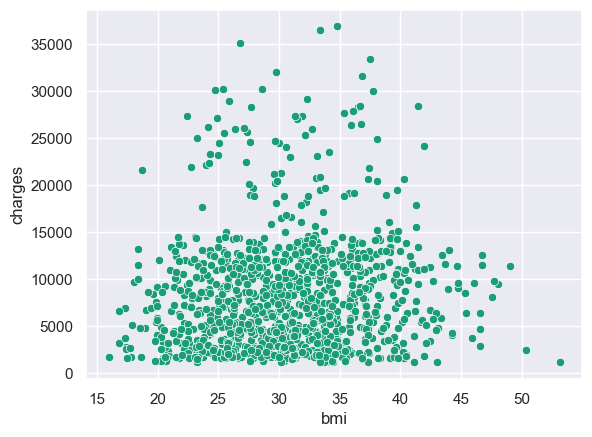

In [68]:
sns.scatterplot(x=non_smoker_df.bmi , y=non_smoker_df.charges)

<Axes: xlabel='age', ylabel='charges'>

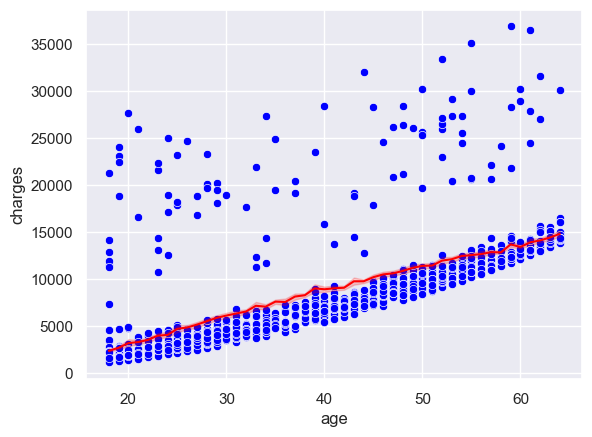

In [69]:
inputs=non_smoker_df[['age' , 'bmi' , 'children']]
output = non_smoker_df.charges

model = LinearRegression().fit(inputs,output)
predictions=model.predict(inputs)
loss=rmse(predictions , output)
loss
sns.scatterplot(x=non_smoker_df.age , y=non_smoker_df.charges , c='b')
sns.lineplot(x=non_smoker_df.age , y=predictions , c='r')

# Adding one hot encoding for the non numeric datas


In [70]:
smoker_codes={'yes':1,
              'no':0
              }

data['smoker_code'] = data.smoker.map(smoker_codes)

In [71]:
sex_codes={
    'male':1,
    'female':0
}

data['sex_code'] = data.sex.map(sex_codes)


## lets check the loss value 

In [72]:
inputs=data[['age','bmi','children','sex_code','smoker_code']]
output=data.charges
model=LinearRegression().fit(inputs,output)
predictions=model.predict(inputs)
loss=rmse(predictions , data.charges)
loss

np.float64(6056.100708754546)

# Lets add onehotencoder

In [73]:
from sklearn.preprocessing import OneHotEncoder
enc=OneHotEncoder()
enc.fit(data[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [74]:
onehot=enc.transform(data[['region']]).toarray()

In [75]:
data[['northeast' , 'northwest' , 'southeast' , 'southwest']]=onehot

In [76]:
data

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [77]:
inputs=data[['age','bmi','children','sex_code','smoker_code','northeast','northwest','southeast','southwest']]
output=data.charges
model=LinearRegression().fit(inputs,output)
predictions=model.predict(inputs)
loss=rmse(predictions , data.charges)
loss

np.float64(6041.679651174452)

C:\Users\anime\AppData\Local\Temp\ipykernel_10912\1040558562.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


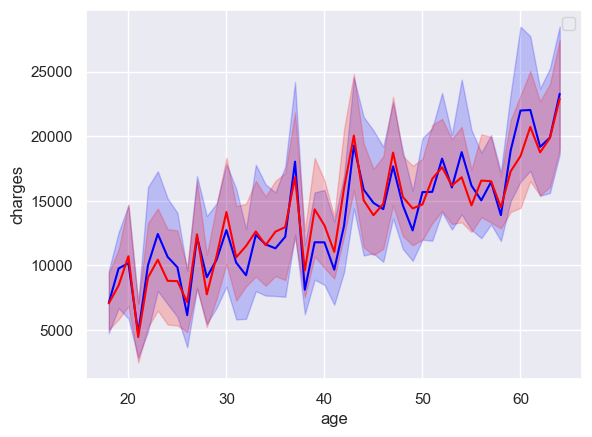

In [78]:
sns.lineplot(x=data.age , y=data.charges,c='b')
sns.lineplot(x=data.age , y=predictions , c='r')
plt.legend()
plt.show()

<Axes: xlabel='bmi', ylabel='charges'>

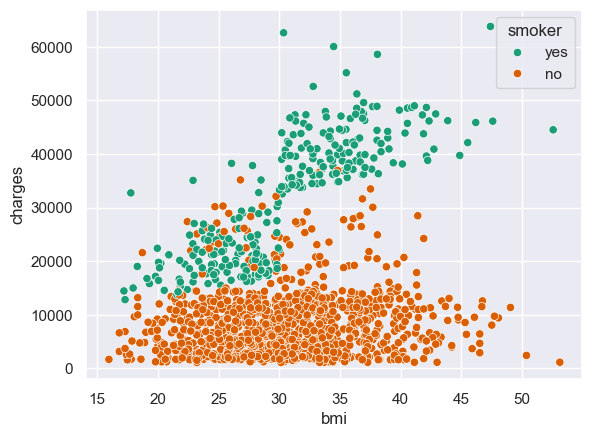

In [79]:
sns.scatterplot(x=data.bmi , y=data.charges,hue=data.smoker)

np.float64(4573.074988795493)

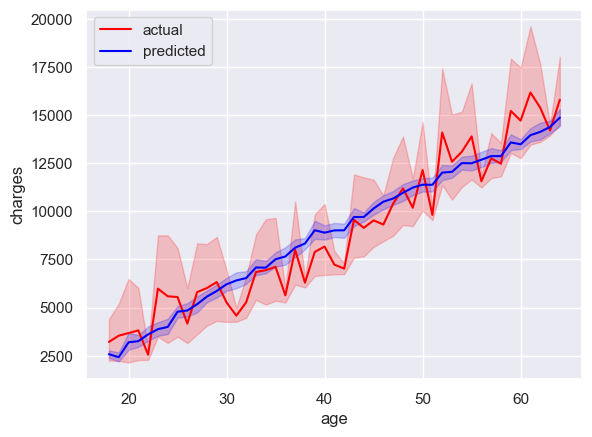

In [80]:
non_smoker_df=data[data.smoker_code==0]
model = LinearRegression();
inputs=non_smoker_df[['age','bmi','children','sex_code','smoker_code','northeast','northwest','southeast','southwest']]
output=non_smoker_df.charges
model.fit(inputs , output);
pred = model.predict(inputs)
sns.lineplot(x=non_smoker_df.age , y=non_smoker_df.charges,c='r',label='actual')
sns.lineplot(x=non_smoker_df.age , y=pred,c='b',label='predicted')
rmse(pred,output)

np.float64(5668.4678821121515)

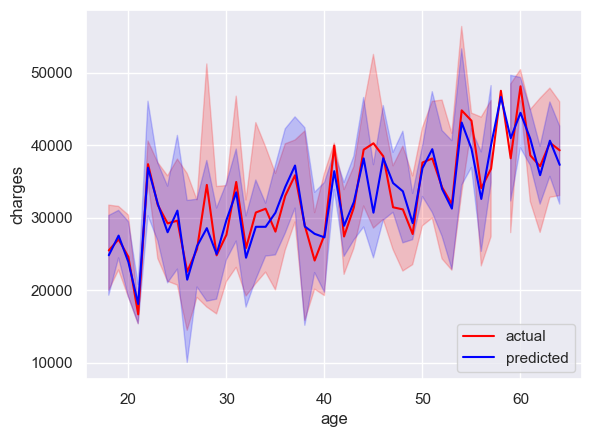

In [81]:
smoker_df=data[data.smoker_code==1]
model = LinearRegression();
inputs=smoker_df[['age','bmi','children','sex_code','smoker_code','northeast','northwest','southeast','southwest']]
output=smoker_df.charges
model.fit(inputs , output);
pred = model.predict(inputs)
sns.lineplot(x=smoker_df.age , y=smoker_df.charges,c='r',label='actual')
sns.lineplot(x=smoker_df.age , y=pred,c='b',label='predicted')
rmse(pred,output)

In [82]:
data

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [83]:
inputs=data.drop(['sex' , 'smoker' ,'region' ],axis=1)
output=data.charges

In [84]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(inputs , output , test_size=0.2)

In [85]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)


In [86]:
from  sklearn.linear_model import LinearRegression
alg=LinearRegression().fit(x_train,y_train) 
predicted=alg.predict(x_test)
                                                                                                   

In [87]:
new_predicted_df = pd.DataFrame({
    'y':list(y_test),
    'predicted':predicted
})
new_predicted_df

,y,predicted
0,14394.55790,13929.820673
1,2897.32350,2860.619148
2,13041.92100,12627.541367
3,20420.60465,19731.522504
4,5757.41345,5614.230229
...,...,...
263,7441.50100,7235.620541
264,6781.35420,6600.050480
265,8277.52300,8040.518108
266,8871.15170,8612.046485


In [88]:
from sklearn.metrics import mean_squared_error , r2_score
print(mean_squared_error(y_test,predicted))
print(r2_score(y_test,predicted))

405647.76067068597
0.9973930980138566


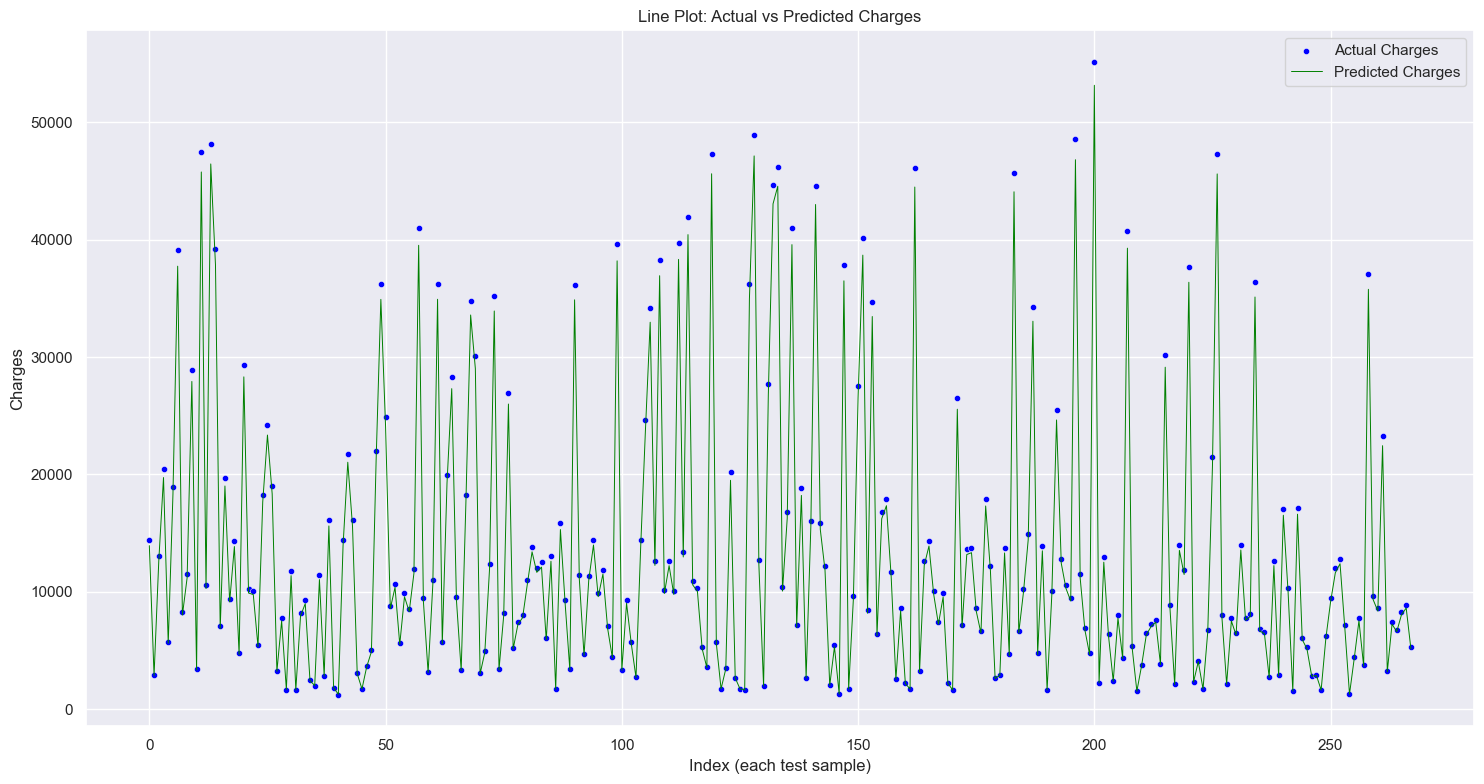

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

new_predicted_df = new_predicted_df.reset_index(drop=True)

plt.figure(figsize=(15, 8))
sns.scatterplot(x=new_predicted_df.index, y='y', data=new_predicted_df,
                label='Actual Charges', color='blue', s=20)

sns.lineplot(x=new_predicted_df.index, y='predicted', data=new_predicted_df,
             label='Predicted Charges', color='green', linewidth=0.7)

plt.title("Line Plot: Actual vs Predicted Charges")
plt.xlabel("Index (each test sample)")
plt.ylabel("Charges")
plt.legend()
plt.tight_layout()
plt.show()
